# Fine-Tuning Strategies for Transfer Learning: Frozen vs. Partial vs. Full Fine-Tuning

**Research question**: How does the depth of fine-tuning on a pretrained CNN affect classification accuracy and training cost, when adapting a large-scale ImageNet model to a fine-grained, smaller dataset?

**Dataset**: Oxford-IIIT Pet (37 breed classes, ~7,400 images).

**Model**: ResNet50 (ImageNet-pretrained).

**Conditions compared**: 
- frozen backbone (only classifier unfrozen, everything else frozen)
- partial fine-tuning (final block + classifier unfrozen)
- full fine-tuning (entire network trainable)
   
**Measuring**: validation/test accuracy, convergence speed, training time per epoch, and number of trainable parameters, to characterize the accuracy–efficiency tradeoff across the three regimes.

**Hypothesis**: we expect full fine-tuning to get the highest accuracy but at the cost of training time, and partial fine-runing sitting between the two extremes


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Dataset & Preprocessing

First resize the images in the dataset to 224×224 and normalize with ImageNet statistics to match ResNet50's pretraining distribution. Training data uses horizontal flip augmentation but validation/test does not, to give an unbiased performance estimate.

In [3]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),          # ResNet expects 224x224
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats — must match
                          std=[0.229, 0.224, 0.225]),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225]),
])

train_val_dataset_train_tf = datasets.OxfordIIITPet(root="./data", split="trainval", download=True, transform=transform_train)
train_val_dataset_test_tf = datasets.OxfordIIITPet(root="./data", split="trainval", download=False, transform=transform_test)
test_dataset = datasets.OxfordIIITPet(root="./data", split="test", download=True, transform=transform_test)

from torch.utils.data import Subset
train_size = int(0.85 * len(train_val_dataset_train_tf))
val_size = len(train_val_dataset_train_tf) - train_size
indices = torch.randperm(len(train_val_dataset_train_tf)).tolist()
train_indices, val_indices = indices[:train_size], indices[train_size:]

train_ds = Subset(train_val_dataset_train_tf, train_indices)
val_ds = Subset(train_val_dataset_test_tf, val_indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = train_val_dataset_train_tf.classes
print(f"Classes: {len(class_names)} | Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_dataset)}")

100%|██████████| 792M/792M [00:03<00:00, 223MB/s]  
100%|██████████| 19.2M/19.2M [00:00<00:00, 107MB/s] 


Classes: 37 | Train: 3128 | Val: 552 | Test: 3669


# Model Setup: Three Fine-Tuning Strategies

build_model() controls how much of ResNet50 is trainable. The partial condition is also tested since real-world transfer learning mostly sits between frozen backbone and full fine tuning.

In [4]:
def build_model(mode: str):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    if mode == "frozen":
        for param in model.parameters():
            param.requires_grad = False
    elif mode == "partial":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.layer4.parameters(): # unfreeze last residual block
            param.requires_grad = True
    elif mode == "full":
        pass 

    num_classes = len(class_names)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

In [5]:
def train_model(model, train_loader, val_loader, epochs=10, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Trainable params: {trainable_params:,} / {total_params:,} ({100*trainable_params/total_params:.1f}%)")
    
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        
        train_loss = running_loss / total
        train_acc = correct / total
        
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += labels.size(0)
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        scheduler.step(val_loss)
        
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        
        print(f"Epoch {epoch+1}/{epochs} | Train Loss {train_loss:.3f} Acc {train_acc:.3f} | "
              f"Val Loss {val_loss:.3f} Acc {val_acc:.3f} | LR {optimizer.param_groups[0]['lr']:.6f}")
    total_time = time.time() - start_time
    print(f"Total training time: {total_time:.1f}s ({total_time/epochs:.1f}s/epoch)")
    history["train_time"] = total_time
    history["trainable_params"] = trainable_params
    return history

# Fine tuning runs with parameters kept constant acrosss runs to evaluate results of fine tuning
10 epochs, lr = 0.001 across all 3 runs


## Frozen Backbone 
Training only the classifier

In [9]:
print("FROZEN BACKBONE")
frozen_model = build_model(mode="frozen")
frozen_history = train_model(frozen_model, train_loader, val_loader, epochs=10, lr=0.001)

FROZEN BACKBONE
Trainable params: 75,813 / 23,583,845 (0.3%)
Epoch 1/10 | Train Loss 2.042 Acc 0.659 | Val Loss 1.060 Acc 0.897 | LR 0.001000
Epoch 2/10 | Train Loss 0.652 Acc 0.927 | Val Loss 0.575 Acc 0.917 | LR 0.001000
Epoch 3/10 | Train Loss 0.372 Acc 0.951 | Val Loss 0.443 Acc 0.922 | LR 0.001000
Epoch 4/10 | Train Loss 0.261 Acc 0.966 | Val Loss 0.374 Acc 0.920 | LR 0.001000
Epoch 5/10 | Train Loss 0.202 Acc 0.975 | Val Loss 0.319 Acc 0.928 | LR 0.001000
Epoch 6/10 | Train Loss 0.159 Acc 0.981 | Val Loss 0.311 Acc 0.929 | LR 0.001000
Epoch 7/10 | Train Loss 0.133 Acc 0.986 | Val Loss 0.273 Acc 0.933 | LR 0.001000
Epoch 8/10 | Train Loss 0.113 Acc 0.989 | Val Loss 0.276 Acc 0.933 | LR 0.001000
Epoch 9/10 | Train Loss 0.099 Acc 0.991 | Val Loss 0.259 Acc 0.928 | LR 0.001000
Epoch 10/10 | Train Loss 0.084 Acc 0.994 | Val Loss 0.248 Acc 0.935 | LR 0.001000
Total training time: 143.8s (14.4s/epoch)


## Partial Fine-Tuning

Unfreezing only layer4 (the final residual block) tests whether adapting high-level, task-specific features is enough, without the cost of retraining the entire backbone.

In [10]:
print("PARTIAL FINETUNE (layer4 unfrozen)")
partial_model = build_model(mode="partial")
partial_history = train_model(partial_model, train_loader, val_loader, epochs=10, lr=0.001)

PARTIAL FINETUNE (layer4 unfrozen)
Trainable params: 15,040,549 / 23,583,845 (63.8%)
Epoch 1/10 | Train Loss 1.039 Acc 0.718 | Val Loss 0.624 Acc 0.822 | LR 0.001000
Epoch 2/10 | Train Loss 0.352 Acc 0.889 | Val Loss 0.436 Acc 0.902 | LR 0.001000
Epoch 3/10 | Train Loss 0.168 Acc 0.950 | Val Loss 0.388 Acc 0.889 | LR 0.001000
Epoch 4/10 | Train Loss 0.115 Acc 0.968 | Val Loss 0.476 Acc 0.864 | LR 0.001000
Epoch 5/10 | Train Loss 0.097 Acc 0.971 | Val Loss 0.449 Acc 0.882 | LR 0.001000
Epoch 6/10 | Train Loss 0.065 Acc 0.984 | Val Loss 0.332 Acc 0.904 | LR 0.001000
Epoch 7/10 | Train Loss 0.074 Acc 0.980 | Val Loss 0.454 Acc 0.888 | LR 0.001000
Epoch 8/10 | Train Loss 0.059 Acc 0.982 | Val Loss 0.400 Acc 0.899 | LR 0.001000
Epoch 9/10 | Train Loss 0.052 Acc 0.985 | Val Loss 0.315 Acc 0.913 | LR 0.001000
Epoch 10/10 | Train Loss 0.047 Acc 0.987 | Val Loss 0.509 Acc 0.902 | LR 0.001000
Total training time: 185.4s (18.5s/epoch)


## Full Fine tuning 
training the entire resnet50 model, with no layers frozen 

In [11]:
print("FULL FINETUNE")
finetune_model = build_model(mode="full")
finetune_history = train_model(finetune_model, train_loader, val_loader, epochs=10, lr=0.001)

FULL FINETUNE
Trainable params: 23,583,845 / 23,583,845 (100.0%)
Epoch 1/10 | Train Loss 1.412 Acc 0.602 | Val Loss 1.602 Acc 0.560 | LR 0.001000
Epoch 2/10 | Train Loss 0.687 Acc 0.782 | Val Loss 1.244 Acc 0.636 | LR 0.001000
Epoch 3/10 | Train Loss 0.496 Acc 0.846 | Val Loss 1.023 Acc 0.716 | LR 0.001000
Epoch 4/10 | Train Loss 0.346 Acc 0.895 | Val Loss 0.824 Acc 0.777 | LR 0.001000
Epoch 5/10 | Train Loss 0.306 Acc 0.902 | Val Loss 0.845 Acc 0.779 | LR 0.001000
Epoch 6/10 | Train Loss 0.244 Acc 0.924 | Val Loss 1.152 Acc 0.699 | LR 0.001000
Epoch 7/10 | Train Loss 0.213 Acc 0.934 | Val Loss 0.846 Acc 0.775 | LR 0.000500
Epoch 8/10 | Train Loss 0.079 Acc 0.975 | Val Loss 0.518 Acc 0.864 | LR 0.000500
Epoch 9/10 | Train Loss 0.025 Acc 0.993 | Val Loss 0.513 Acc 0.877 | LR 0.000500
Epoch 10/10 | Train Loss 0.014 Acc 0.995 | Val Loss 0.455 Acc 0.880 | LR 0.000500
Total training time: 384.2s (38.4s/epoch)


# Qualitative check - Sample predictions 
Before quantifying performance, we visually spot-check predictions from each model on random test images to sanity check that training worked as expected

Frozen model predictions:


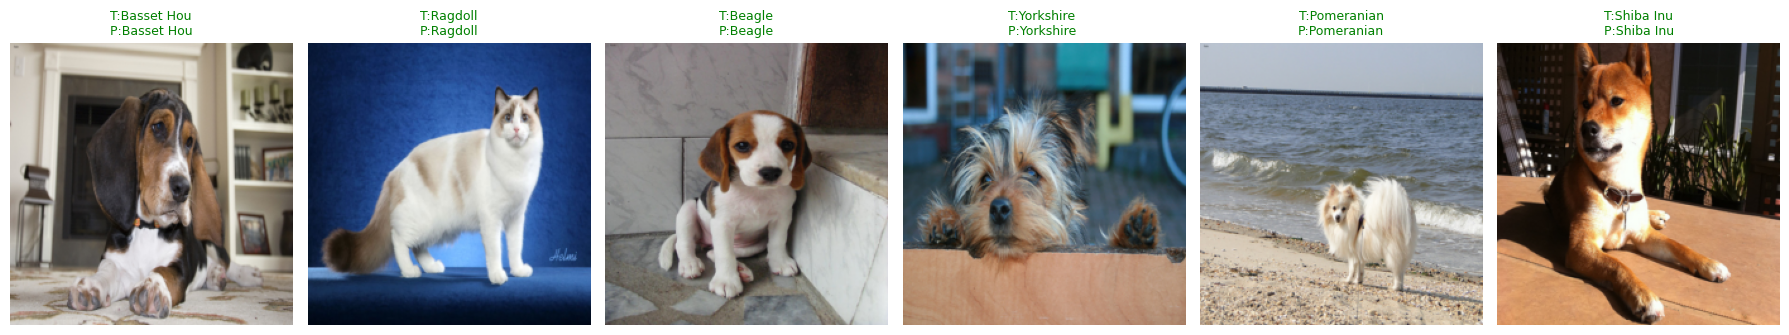

Partial finetune model predictions:


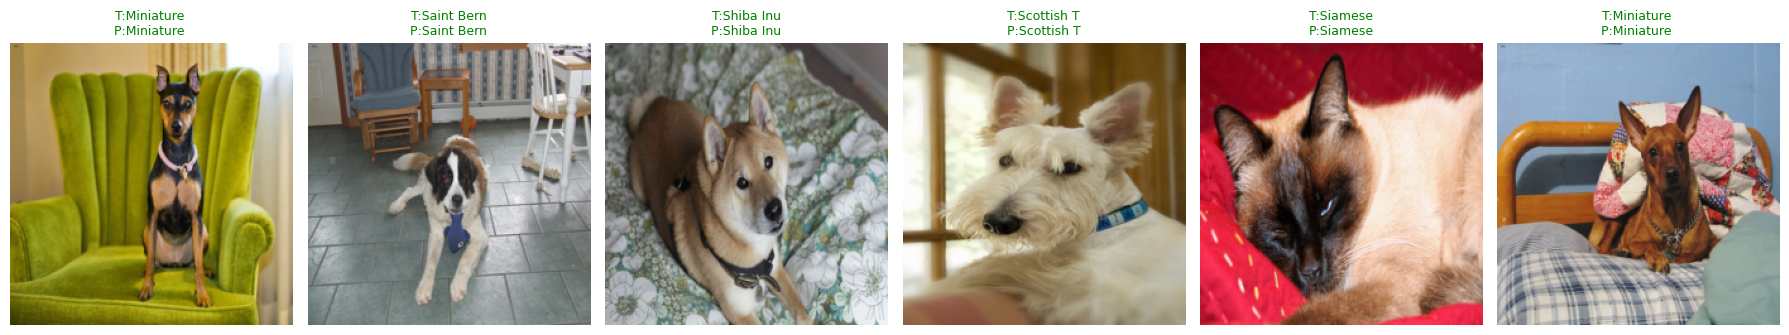

Full finetune model predictions:


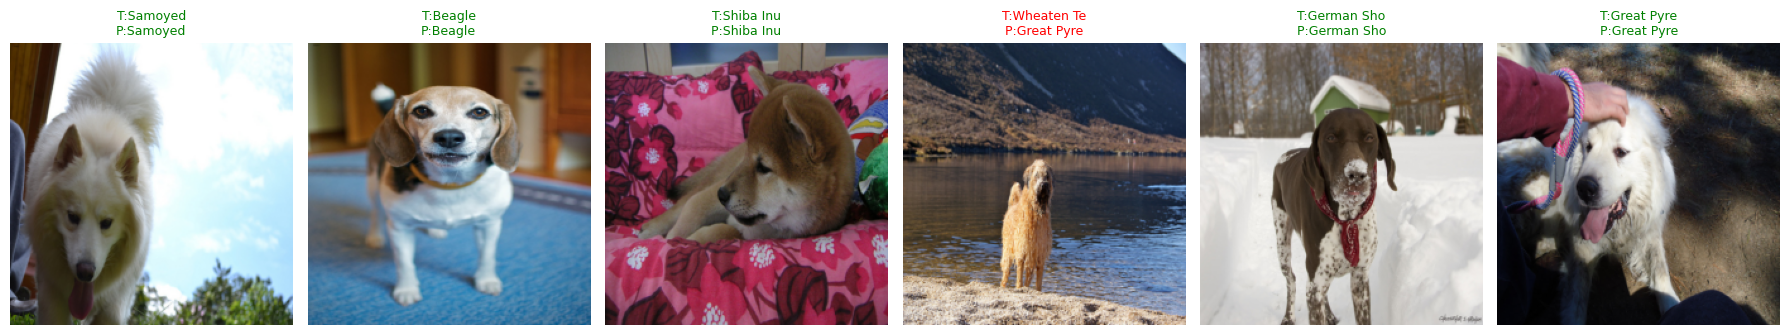

In [13]:
def show_predictions(model, dataset, class_names, n=6):
    model.eval()
    fig, axes = plt.subplots(1, n, figsize=(18, 4))
    indices = np.random.choice(len(dataset), n, replace=False)
    
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    
    for i, idx in enumerate(indices):
        img, label = dataset[idx]
        with torch.no_grad():
            pred = model(img.unsqueeze(0).to(device)).argmax(1).item()
        
        img_show = (img * std + mean).permute(1, 2, 0).clamp(0, 1)
        axes[i].imshow(img_show)
        color = "green" if pred == label else "red"
        axes[i].set_title(f"T:{class_names[label][:10]}\nP:{class_names[pred][:10]}", color=color, fontsize=9)
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()

print("Frozen model predictions:")
show_predictions(frozen_model, test_dataset, class_names)

print("Partial finetune model predictions:")
show_predictions(partial_model, test_dataset, class_names)

print("Full finetune model predictions:")
show_predictions(finetune_model, test_dataset, class_names)

# Results Analysis 
We will now plot accuracy and loss curves to compare validation accuracy and loss across all three training runs.

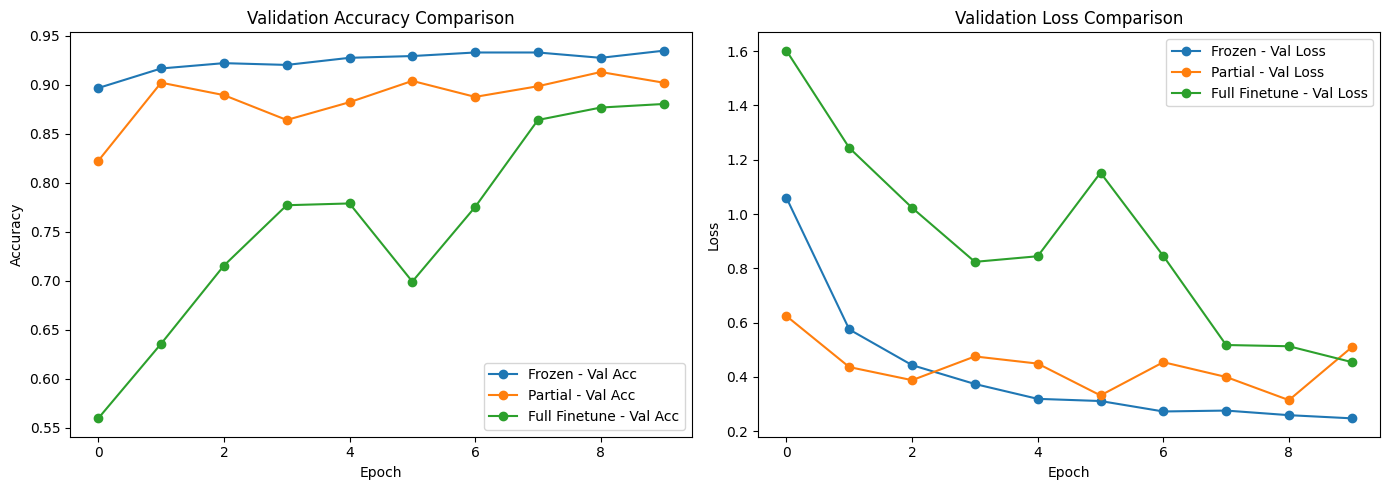

Final Frozen Val Acc:   0.935
Final Partial Val Acc:  0.902
Final Finetune Val Acc: 0.880


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(frozen_history["val_acc"], label="Frozen - Val Acc", marker='o')
axes[0].plot(partial_history["val_acc"], label="Partial - Val Acc", marker='o')
axes[0].plot(finetune_history["val_acc"], label="Full Finetune - Val Acc", marker='o')
axes[0].set_title("Validation Accuracy Comparison")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(frozen_history["val_loss"], label="Frozen - Val Loss", marker='o')
axes[1].plot(partial_history["val_loss"], label="Partial - Val Loss", marker='o')
axes[1].plot(finetune_history["val_loss"], label="Full Finetune - Val Loss", marker='o')
axes[1].set_title("Validation Loss Comparison")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Final Frozen Val Acc:   {frozen_history['val_acc'][-1]:.3f}")
print(f"Final Partial Val Acc:  {partial_history['val_acc'][-1]:.3f}")
print(f"Final Finetune Val Acc: {finetune_history['val_acc'][-1]:.3f}")

## Observation
Most people's first assumption is that more trainable parameters means better performance but contrary to the usual assumption, here is what was observed after conducting experiments: The frozen backbone achieved the highest test accuracy (90.2%), while partial (85.4%) and full fine-tuning (83.0%) both performed worse. Full fine-tuning also took the longest to train (384s vs 144s) and was the least stable early on, where its validation accuracy dropped to 0.56 in epoch 1 before slowly recovering. This is a sign of catastrophic forgetting of the pretrained ImageNet features. With only ~3,100 training images across 37 fine-grained classes, and a single learning rate (0.001) applied uniformly across the entire 23M-parameter backbone, full fine-tuning likely overfit before it could re-converge to a better optimum. This suggests that for small, fine-grained datasets, a frozen or lightly-unfrozen backbone is a stronger default than naive full fine-tuning unless full fine-tuning is paired with discriminative learning rates (lower LR for early layers) and more careful scheduling.

# Confusion Matrices
using confusion matrices to check whether errors are concentrated in specific visually-similar breeds (e.g. cat vs. dog breeds that look alike) rather than spread evenly

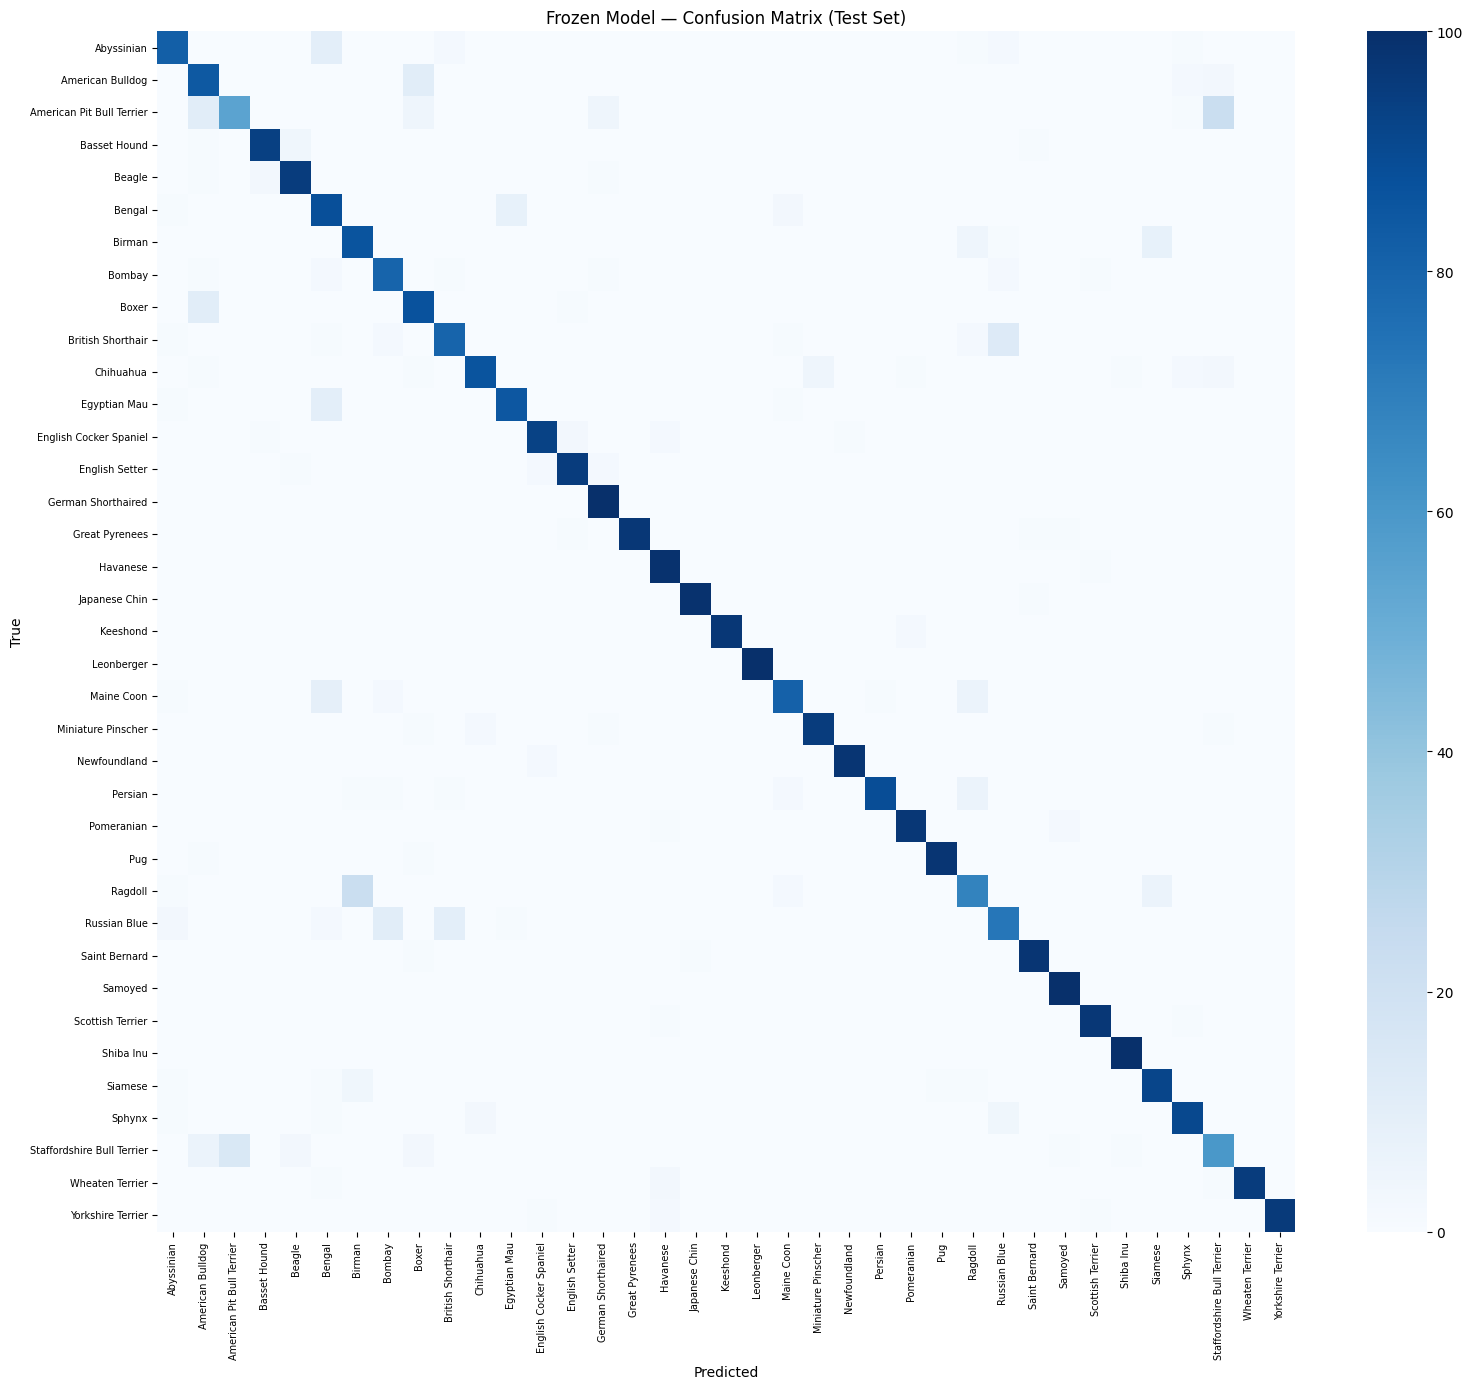

Frozen Model — Confusion Matrix (Test Set) — Test Accuracy: 0.9022


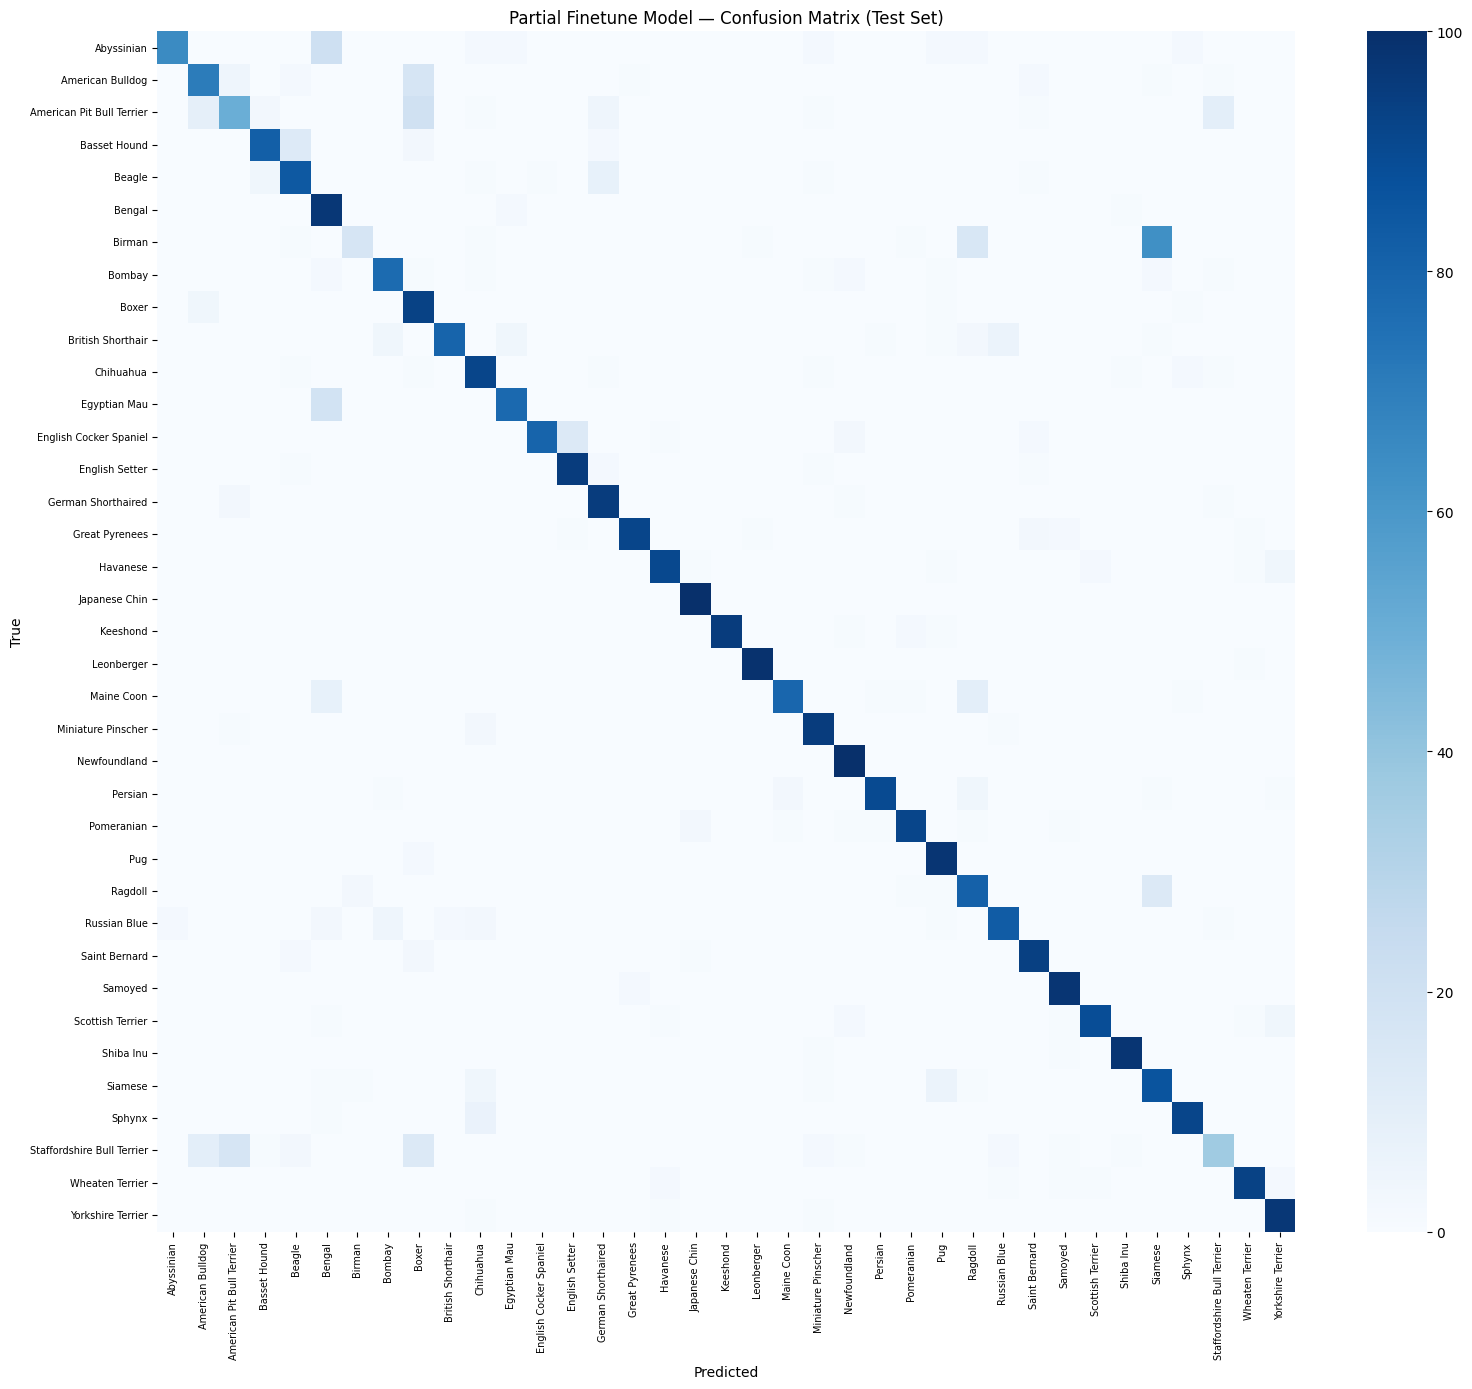

Partial Finetune Model — Confusion Matrix (Test Set) — Test Accuracy: 0.8545


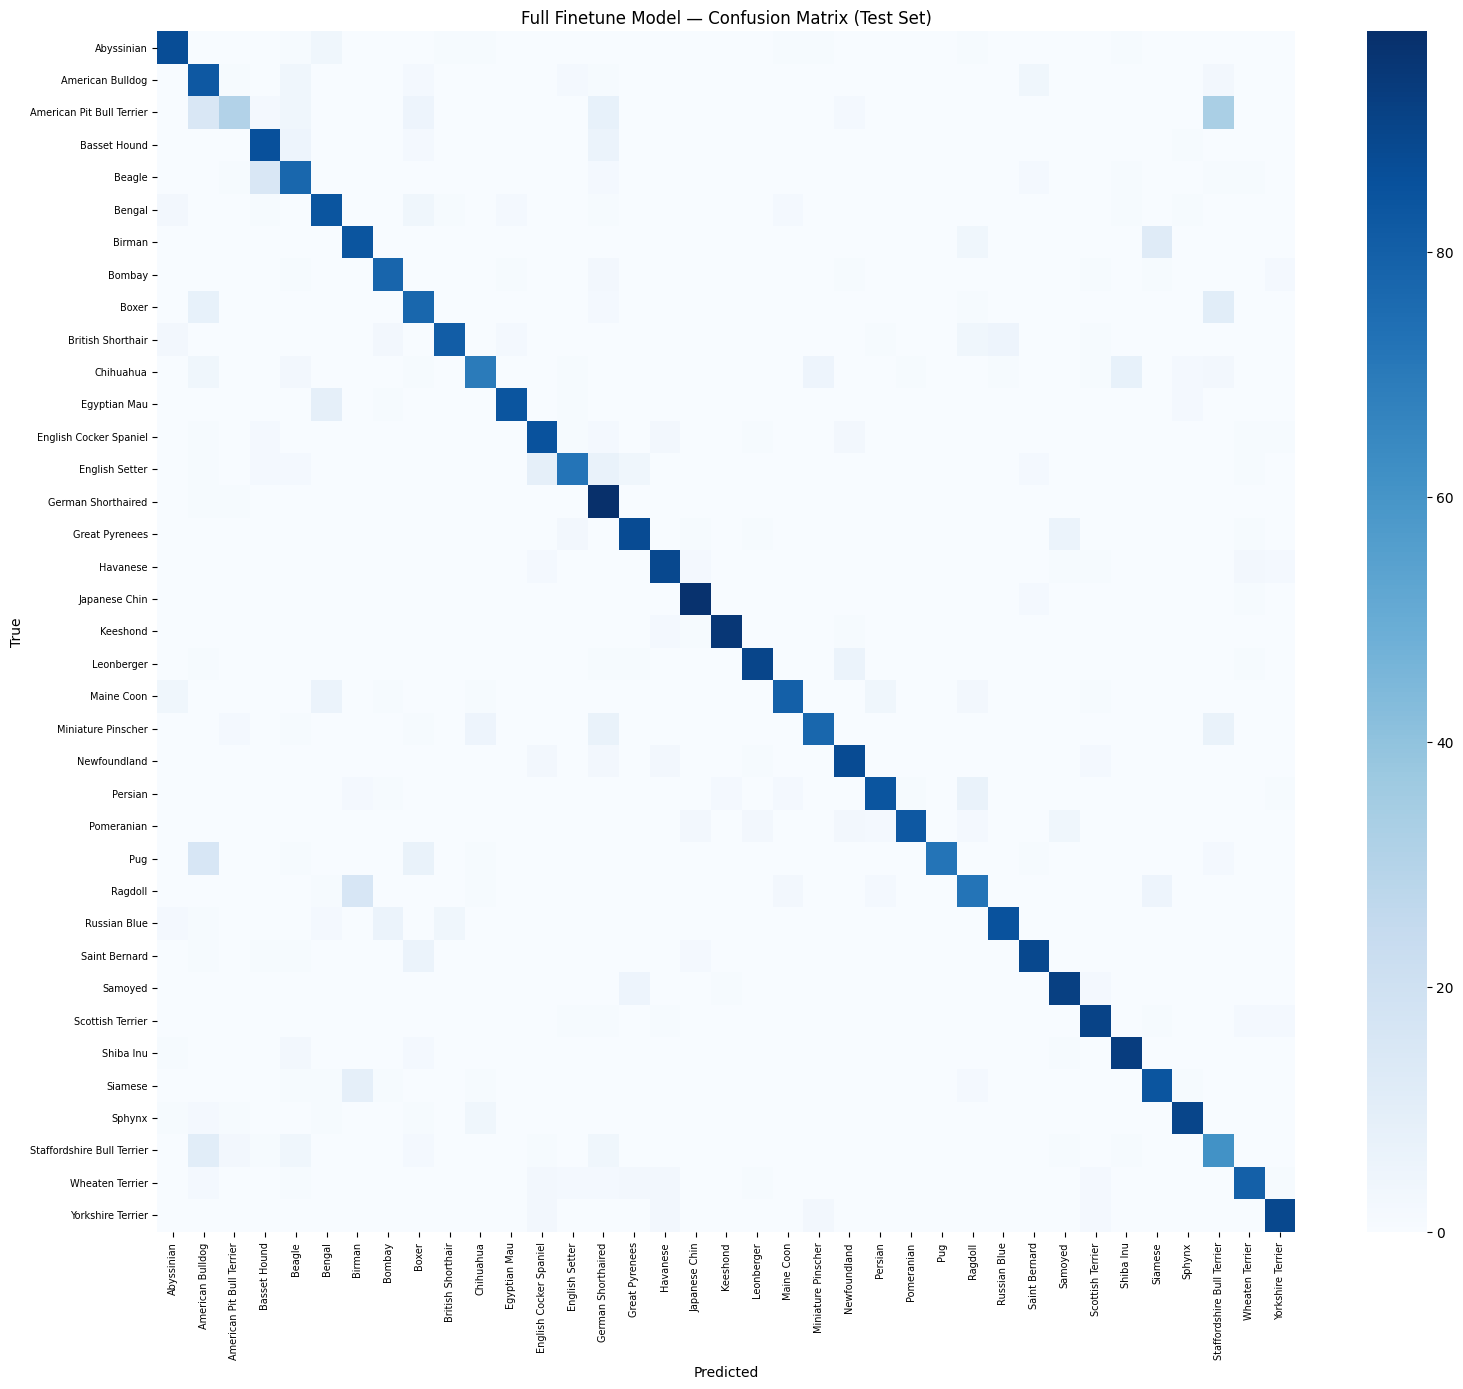

Full Finetune Model — Confusion Matrix (Test Set) — Test Accuracy: 0.8302


In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)

def plot_confusion_matrix(model, loader, class_names, title):
    preds, labels = get_predictions(model, loader)
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=90, fontsize=7); plt.yticks(rotation=0, fontsize=7)
    plt.tight_layout()
    plt.show()
    test_acc = (preds == labels).mean()
    print(f"{title} — Test Accuracy: {test_acc:.4f}")
    return preds, labels

frozen_preds, frozen_labels = plot_confusion_matrix(frozen_model, test_loader, class_names, "Frozen Model — Confusion Matrix (Test Set)")
partial_preds, partial_labels = plot_confusion_matrix(partial_model, test_loader, class_names, "Partial Finetune Model — Confusion Matrix (Test Set)")
finetune_preds, finetune_labels = plot_confusion_matrix(finetune_model, test_loader, class_names, "Full Finetune Model — Confusion Matrix (Test Set)")

## Observation

From the confusion matrices we can see that across all three models, the most consistent error is a confusion between American Pit Bull Terrier and Staffordshire Bull Terrier. This confusion persists at roughly the same magnitude regardless of fine-tuning depth, suggesting it's a limitation of the visual signal itself at 224×224 resolution rather than something more fine-tuning would fix. 

Other than this, errors are spread thinly across the grid which is why the confusion matrices look close to a clean diagonal at ~85-90% accuracy and no single breed is a major outlier. 

The Full Finetune matrix shows more faint diagonal scatter overall which is again consistent with its lower test accuracy but doesn't introduce any new consistently-confused pairs beyond what Frozen already shows

In [15]:
import pandas as pd

frozen_test_acc = (frozen_preds == frozen_labels).mean()
partial_test_acc = (partial_preds == partial_labels).mean()
finetune_test_acc = (finetune_preds == finetune_labels).mean()

results = pd.DataFrame({
    "Model": ["Frozen (feature extraction)", "Partial Finetune (layer4)", "Full Finetune"],
    "Final Train Acc": [
        frozen_history["train_acc"][-1],
        partial_history["train_acc"][-1],
        finetune_history["train_acc"][-1],
    ],
    "Final Val Acc": [
        frozen_history["val_acc"][-1],
        partial_history["val_acc"][-1],
        finetune_history["val_acc"][-1],
    ],
    "Test Acc": [frozen_test_acc, partial_test_acc, finetune_test_acc],
    "Trainable Params": [
        frozen_history["trainable_params"],
        partial_history["trainable_params"],
        finetune_history["trainable_params"],
    ],
    "% of Total Params": [
        100 * frozen_history["trainable_params"] / sum(p.numel() for p in frozen_model.parameters()),
        100 * partial_history["trainable_params"] / sum(p.numel() for p in partial_model.parameters()),
        100 * finetune_history["trainable_params"] / sum(p.numel() for p in finetune_model.parameters()),
    ],
    "Training Time (s)": [
        frozen_history["train_time"],
        partial_history["train_time"],
        finetune_history["train_time"],
    ],
})
results

,Model,Final Train Acc,Final Val Acc,Test Acc,Trainable Params,% of Total Params,Training Time (s)
0,Frozen (feature extraction),0.994246,0.934783,0.902153,75813,0.321462,143.798814
1,Partial Finetune (layer4),0.986893,0.902174,0.854456,15040549,63.774796,185.432568
2,Full Finetune,0.995205,0.880435,0.830199,23583845,100.000000,384.165693


In [16]:
torch.save(frozen_model.state_dict(), "frozen_resnet50.pth")
torch.save(finetune_model.state_dict(), "finetuned_resnet50.pth")
torch.save(partial_model.state_dict(), "partial_resnet50.pth")
print("Models saved.")

Models saved.


# Conclusion

This experiment was done to test whether deeper fine-tuning of a pretrained ResNet50 improves classification accuracy on Oxford-IIIT Pet, at the cost of training time. The result was the opposite of the expectation: the frozen backbone achieved the highest test accuracy (90.2%) outperforming both partial fine-tuning (85.4%) and full fine-tuning (83.0%), while also being the cheapest to train (144s total vs. 185s for partial and 384s for full, using only 0.3% of the model's parameters)

The likely explanation is that our dataset is a small, fine-grained dataset (having approx 3,100 training images across 37 visually similar breeds) which implies that increasing parameters is causing overfitting on the small datatset thus resulting in worse test accuracy upon increasing paramaters. In the full fine-tuning run, validation accuracy collapsed to 0.56 in epoch 1 and took until epoch 8 (after the scheduler halved the learning rate) to recover past the frozen model's very first epoch. This is a sign of catastrophic forgetting where early gradient updates from a randomly-initialized classifier head disrupt the pretrained backbone's already-useful features before the model has a chance to re-stabilize. Partial fine-tuning sits between the two extremes in terms of trainable parameters (63.8%) and training time, but not land between them in accuracy as it underperformed frozen on both validation and test accuracy. This again means that overfitting is occuring as we increase parameters because the dataset is small.

**Efficiency takeaway**: for this dataset size, the frozen backbone is both cheaper and better because it dominates on both accuracy and training cost.

**Limitations**: no random seed was fixed, so exact numbers may shift slightly between runs (though the qualitative ranking is unlikely to flip given the size of the gaps); the validation set is small (552 images); all three runs used a fixed 10 epochs even though they converge at different rates — full fine-tuning was still improving at epoch 10, so its result may understate its ceiling; and all three models were compared using their final-epoch weights rather than the best checkpoint by validation accuracy, which is a minor disadvantage for the runs (partial, full) whose validation accuracy fluctuated near the end rather than monotonically improving.